# Exploratory Data Analysis (EDA)
## Student Performance Dataset

This project analyzes student performance based on various factors such as study hours, attendance, and previous academic records.

In [48]:
#---Import Libraries---
import pandas as pd
import numpy as np

In [49]:
#---Load Dataset---
df = pd.read_csv('/content/Student_Performance_Dataset.csv')

## Dataset Description

The dataset contains information about students including study habits, attendance, subject scores, and final performance.

- Number of records: 5000
- Features include:
  - Study Hours
  - Attendance Percentage
  - Subject Scores
  - Previous Year Score
  - Final Percentage
  - Performance Level
  - Pass/Fail Status

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

#---Basic Understanding---

In [28]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [29]:
df.shape

(5000, 16)

In [30]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')

## Data Cleaning

In this step, we check for missing values and duplicate records to ensure data quality.

In [31]:
#---Check missing values---
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Class,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Parental_Education,0
Internet_Access,0
Extracurricular_Activities,0
Math_Score,0


In [32]:
df.duplicated().sum()

np.int64(0)

#---Separate numerical & categorical columns---

In [33]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['Age', 'Class', 'Study_Hours_Per_Day', 'Attendance_Percentage',
       'Math_Score', 'Science_Score', 'English_Score', 'Previous_Year_Score',
       'Final_Percentage'],
      dtype='object')
Categorical: Index(['Student_ID', 'Gender', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Performance_Level', 'Pass_Fail'],
      dtype='object')


#---Visualization---

## Histogram: Final Percentage Distribution

This histogram shows how the final percentage is distributed among students.

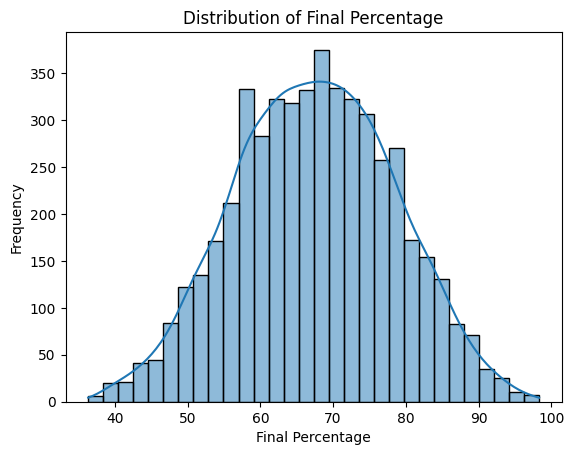

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Final_Percentage'], kde=True, bins=30)
plt.title("Distribution of Final Percentage")
plt.xlabel("Final Percentage")
plt.ylabel("Frequency")
plt.show()

### Insight:
Most students have scores concentrated in the middle range, indicating average performance.

## Count Plot: Gender vs Pass/Fail

This plot shows the distribution of pass and fail students across genders.

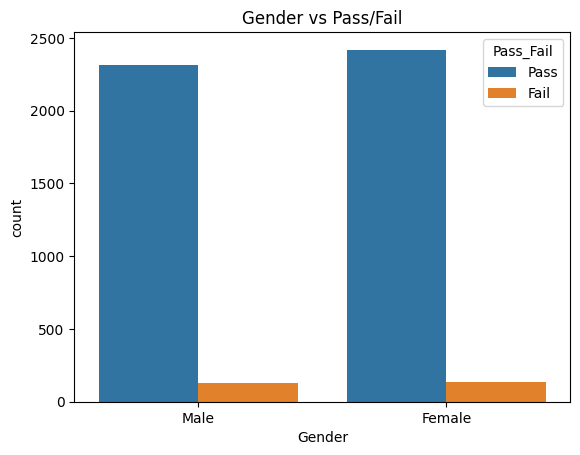

In [36]:
sns.countplot(x='Gender', hue='Pass_Fail', data=df)
plt.title("Gender vs Pass/Fail")
plt.show()


Insight:
The majority of students fall into the pass category across both genders

## 3. Scatter Plot – relationship
### Study Hours vs Final Percentage

This graph shows the relationship between study hours and final performance.

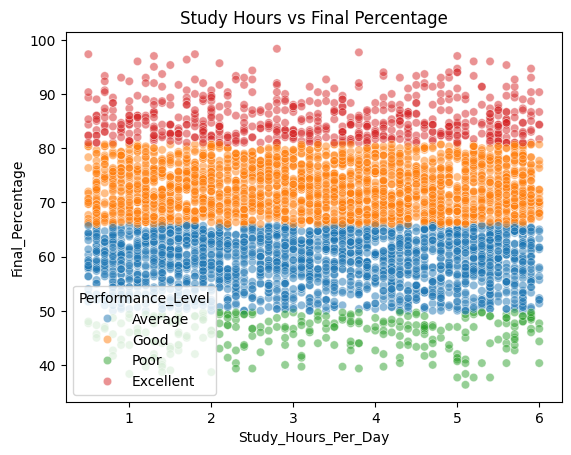

In [37]:
sns.scatterplot(
    x='Study_Hours_Per_Day',
    y='Final_Percentage',
    hue='Performance_Level',
    data=df,
    alpha=0.5
)
plt.title("Study Hours vs Final Percentage")
plt.show()

### Insight:
Students who study more hours tend to achieve higher scores, indicating a positive relationship.

## 4. Box Plot – outliers

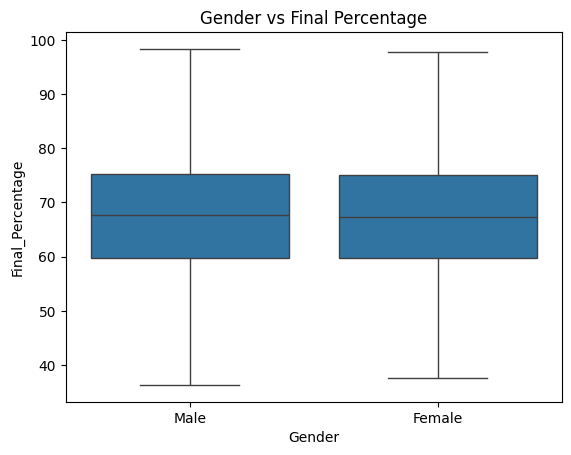

In [39]:
sns.boxplot(
    x='Gender',
    y='Final_Percentage',
    data=df
)
plt.title("Gender vs Final Percentage")
plt.show()

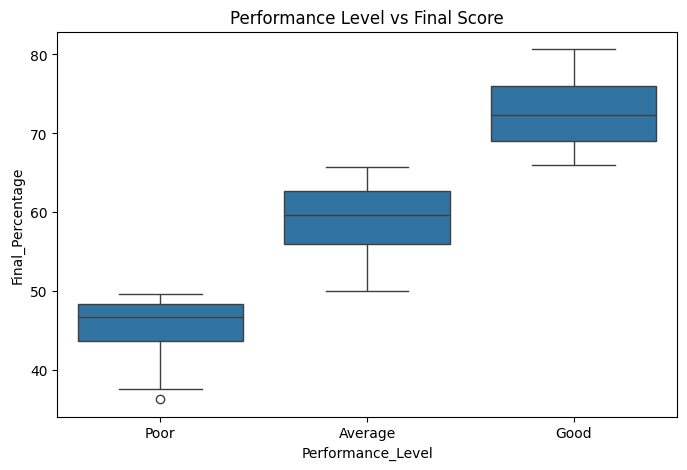

In [47]:
order = ['Poor', 'Average', 'Good']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Performance_Level',
    y='Final_Percentage',
    data=df,
    order=order
)

plt.title("Performance Level vs Final Score")
plt.show()

## Box Plot: Performance Level vs Final Percentage

This plot shows the distribution of scores.

## 5. Heatmap – correlation
### Correlation Between Features

This heatmap displays the correlation between numerical variables in the dataset.

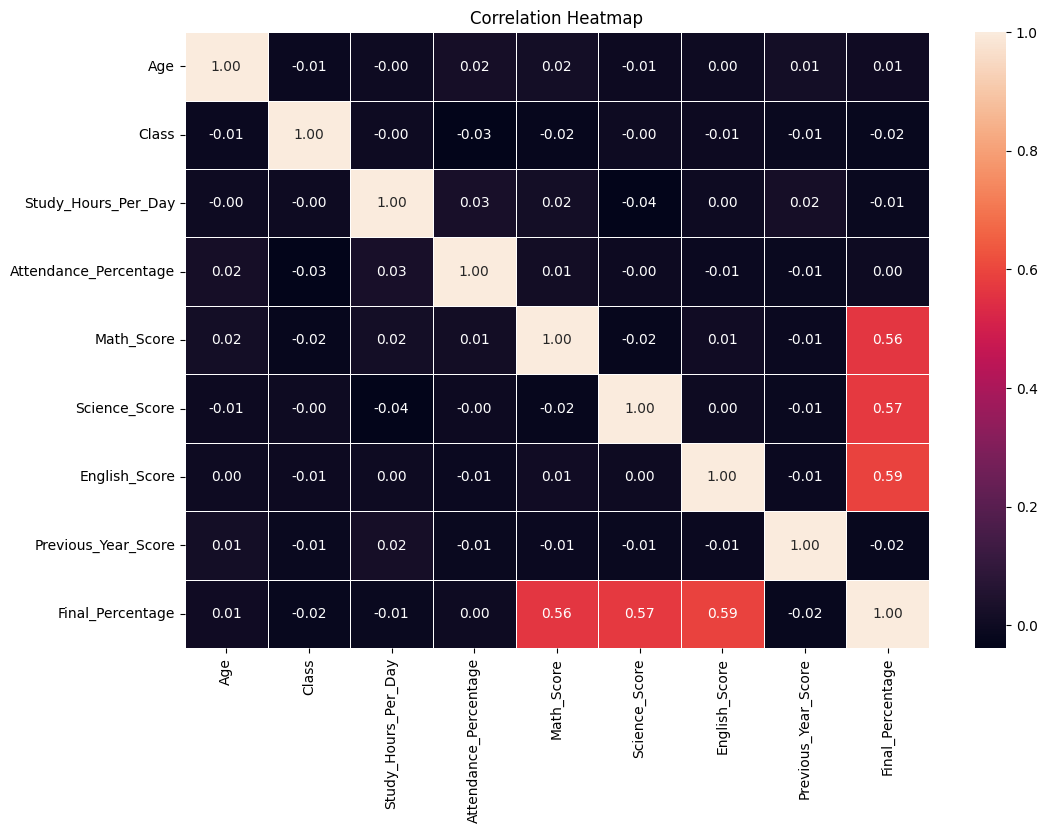

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

### Insight:
Study hours, attendance, and previous scores show strong positive correlation with final percentage.

## 6. Bar Plot

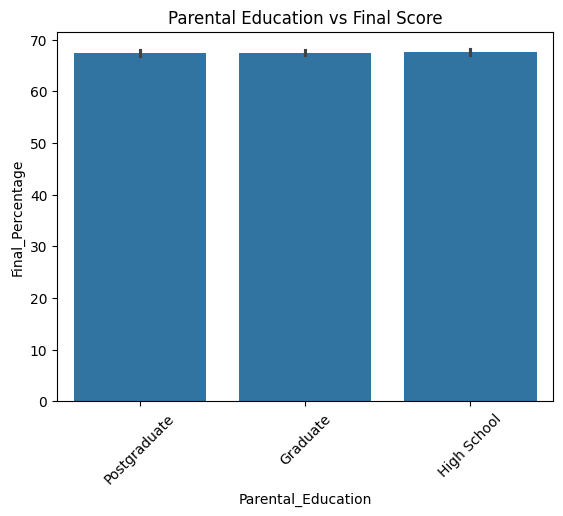

In [41]:
sns.barplot(
    x='Parental_Education',
    y='Final_Percentage',
    data=df
)
plt.xticks(rotation=45)
plt.title("Parental Education vs Final Score")
plt.show()

## 7. Line Chart
### Average Score vs Study Hours

This chart represents how the average score changes with study hours.

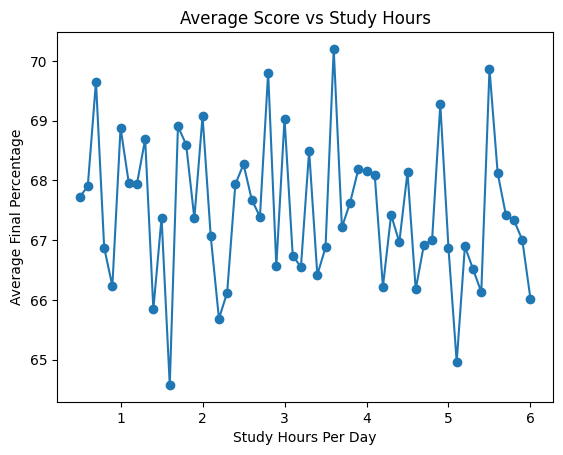

In [42]:
avg_scores = df.groupby('Study_Hours_Per_Day')['Final_Percentage'].mean()

plt.plot(avg_scores.index, avg_scores.values, marker='o')
plt.title("Average Score vs Study Hours")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Final Percentage")
plt.show()

### Insight:
The average score increases as study hours increase, showing a clear trend.

## 8. Pie Chart
### Pass vs Fail Distribution

This chart shows the proportion of students who passed and failed.

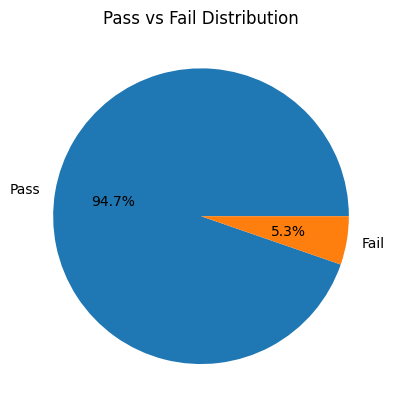

In [43]:
counts = df['Pass_Fail'].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)
plt.title("Pass vs Fail Distribution")
plt.show()

### Insight:
A large proportion of students have passed, indicating overall good performance.

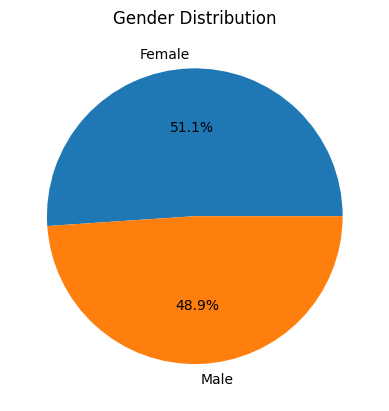

In [44]:
gender_counts = df['Gender'].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()

## Key Insights

- Study hours have a strong impact on student performance
- Attendance plays an important role in scoring well
- Previous academic performance influences final results
- Higher performance levels correspond to higher scores

## Conclusion

The analysis shows that consistent study habits, good attendance, and strong academic background significantly influence student performance. These factors should be considered for improving student outcomes.